Importing

In [174]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

loading csv

In [140]:
df = pd.read_csv("data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


create column "Country"

In [141]:
df["Country"]="tanzania"

changing date

In [142]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Date"].head()

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]

change month to name

In [143]:

df["Month_Name"] = df["Date"].dt.month_name()

replace -999 with Nan if exist

In [144]:
df = df.replace(-999, np.nan, inplace=True)

check for duplicate row and return how many

In [145]:
df.duplicated().sum()

np.int64(0)


The dataset was checked for duplicate rows using df.duplicated().sum(). The result showed 0 duplicate rows, indicating that all observations are unique. 
Therefore, no rows were removed during the deduplication step.

In [146]:
df = df.drop_duplicates()

describe 

In [147]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN


The dataset contains 4,108 observations from 2015 to 2026 with no missing values, confirming high data quality and completeness. The average temperature (T2M) is 26.8°C, with low variability, indicating a consistently warm and stable climate, while the daily temperature range averages 4.13°C, suggesting limited day–night variation. Precipitation (PRECTOTCORR) has a mean of 3.74 mm but reaches up to 122.65 mm, showing a highly right-skewed distribution with occasional extreme rainfall events. Humidity is relatively high (mean ≈ 77%), and wind speeds are moderate, whereas surface pressure remains very stable. Z-score analysis identified 97 outlier rows, primarily associated with precipitation and wind variables, reflecting extreme but realistic weather events rather than data errors. Overall, the dataset represents a warm, moderately humid, and stable climate with irregular but sometimes intense rainfall, making it suitable for further statistical and trend analysis.

number of Nan

In [148]:
df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

MIssing value >5%

In [149]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

The percentage of missing values was computed for all columns. The results show that all variables have 0.0% missing values. 
No column exceeds the 5% threshold, indicating that the dataset is complete and suitable for analysis without requiring imputation or removal of variables.

identify outlier using z-score

In [150]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [151]:
z_scores = np.abs(stats.zscore(df[cols]))

In [152]:
outliers_mask=(z_scores>3).any(axis=1)

In [153]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 97


Z-score analysis was conducted on key climate variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX) using a threshold of |Z| > 3 to detect extreme values. The analysis identified 97 rows as outliers, indicating the presence of notable but not excessive extreme observations in the dataset. These outliers are primarily associated with precipitation and wind variables, which tend to exhibit higher variability, as well as occasional temperature extremes. In the context of climate data, such values often represent real-world extreme weather events rather than data errors. Therefore, it is advisable to retain these outliers for analysis, while optionally applying methods such as capping or log transformation (especially for precipitation) to reduce their impact on statistical modeling and visualization.

Handling missing values

In [154]:
threshold = int(0.3 * len(df.columns))

df = df[df.isna().sum(axis=1) <= threshold]


Forward-fill weather variables

In [155]:
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month_Name     0
dtype: int64

cleaned

In [156]:
df_clean = df[~outliers_mask].copy()

In [157]:
print(f"Cleaned rows:{len(df)}")

Cleaned rows:4108


In [158]:
df.to_csv("data/tanzania_clean.csv", index=False)

In [159]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

In [160]:
print(df_clean.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date',
       'Month_Name'],
      dtype='str')


In [161]:
for col in df.columns:
    print(repr(col))


'YEAR'
'DOY'
'T2M'
'T2M_MAX'
'T2M_MIN'
'T2M_RANGE'
'PRECTOTCORR'
'RH2M'
'WS2M'
'WS2M_MAX'
'PS'
'QV2M'
'Country'
'Date'
'Month_Name'


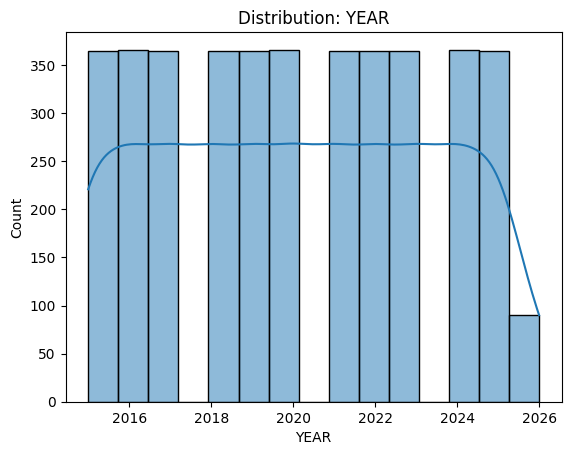

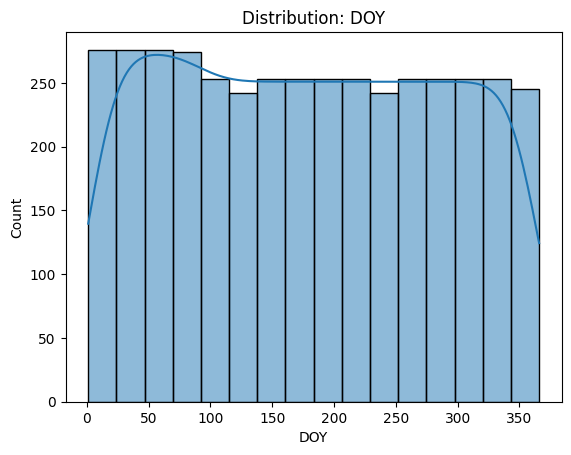

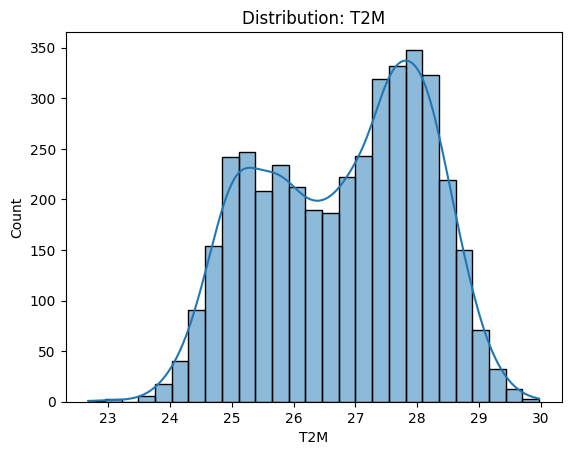

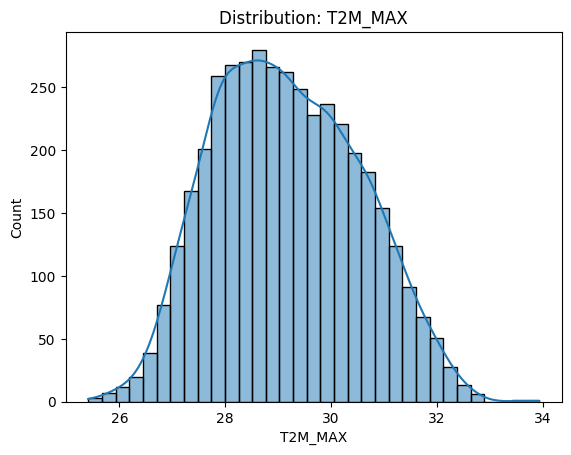

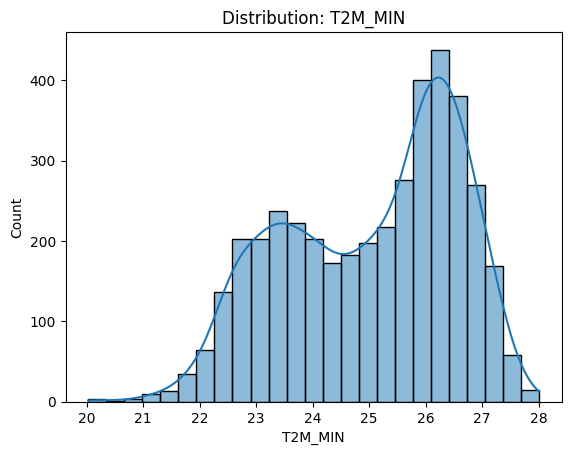

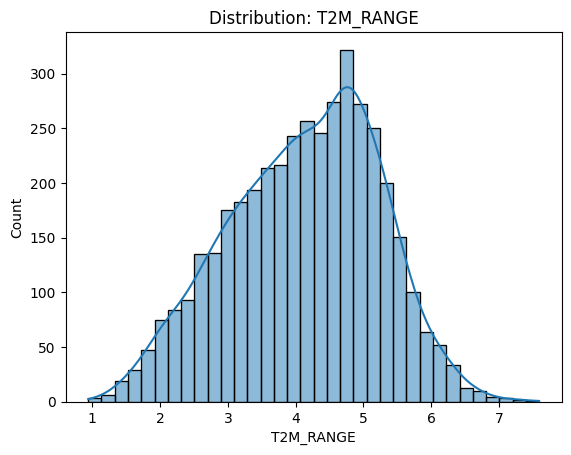

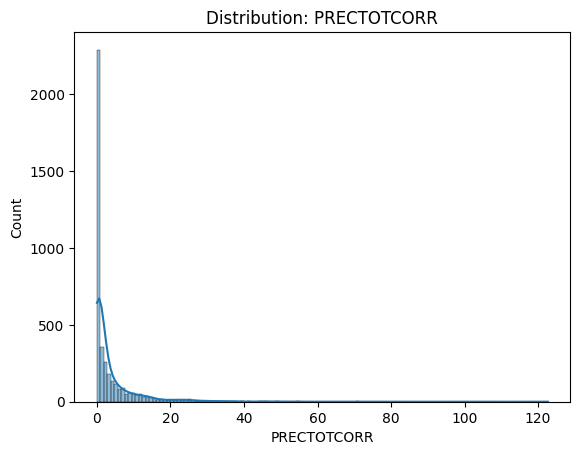

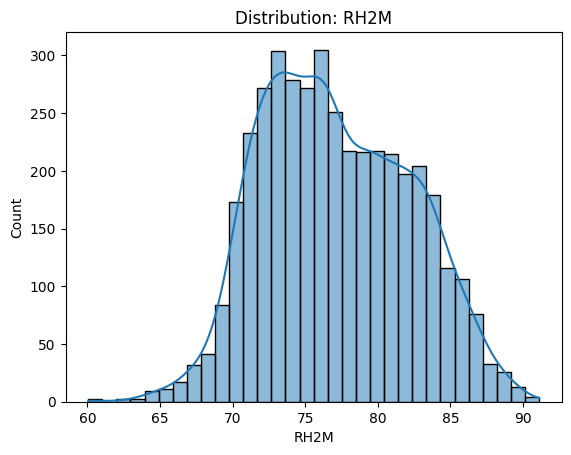

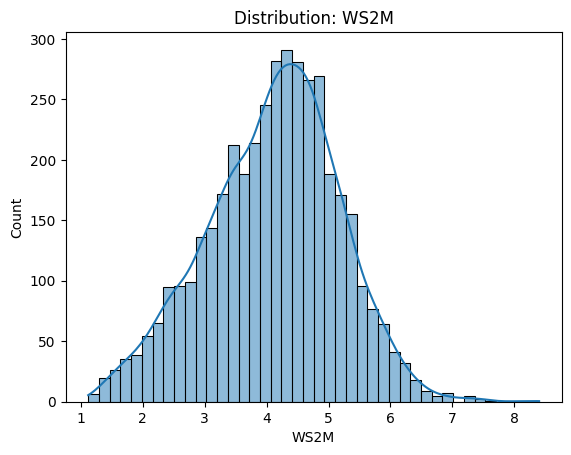

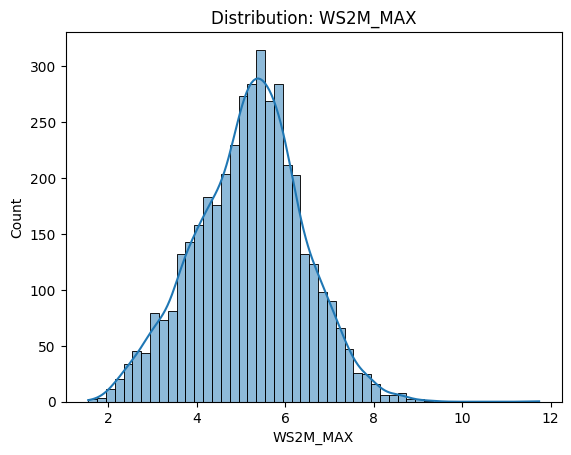

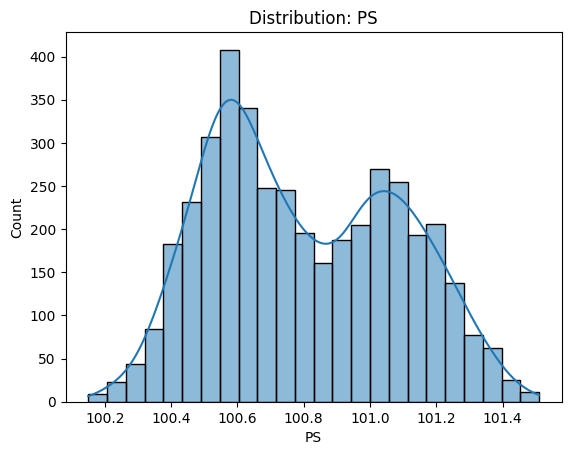

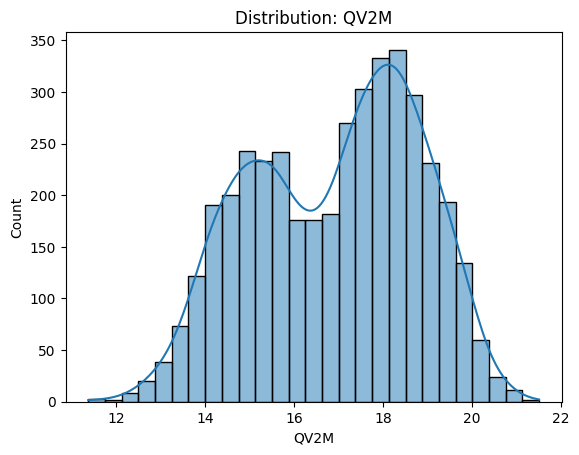

In [162]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    plt.figure()
    sns.histplot(df[c], kde=True)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

In [163]:

df_clean = df[~outliers_mask].copy()

Monthly average T2M

In [164]:

# Set Date as index for resampling
df_clean = df_clean.set_index("Date")

In [165]:

monthly_t2m = df_clean["T2M"].resample("ME").mean()

Find warmest and coolest months

In [166]:

warmest_month = monthly_t2m.idxmax()
coolest_month = monthly_t2m.idxmin()
warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()


plot

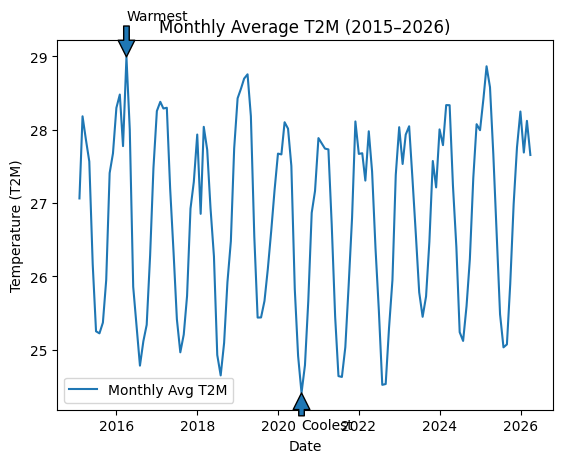

In [167]:
# Plot
plt.plot(monthly_t2m, label="Monthly Avg T2M")
# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_month, warmest_value),
             xytext=(warmest_month, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_month, coolest_value),
             xytext=(coolest_month, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

BAR chart for PRECTOTCORR

In [168]:
print(df_clean.head())

            YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
Date                                                                            
2015-01-01  2015    1  27.56    29.52    26.22       3.30         7.24  80.97   
2015-01-02  2015    2  27.59    29.99    25.92       4.07         3.40  79.63   
2015-01-03  2015    3  27.47    29.29    26.25       3.04         7.17  80.02   
2015-01-04  2015    4  27.28    29.17    25.96       3.21        16.07  81.78   
2015-01-05  2015    5  26.68    27.83    25.84       1.99        18.83  82.99   

            WS2M  WS2M_MAX      PS   QV2M   Country Month_Name  
Date                                                            
2015-01-01  4.68      6.01  100.52  18.61  tanzania    January  
2015-01-02  4.48      5.28  100.52  18.31  tanzania    January  
2015-01-03  4.91      5.99  100.56  18.30  tanzania    January  
2015-01-04  4.88      6.07  100.47  18.52  tanzania    January  
2015-01-05  4.17      5.98  100.43  18.16 

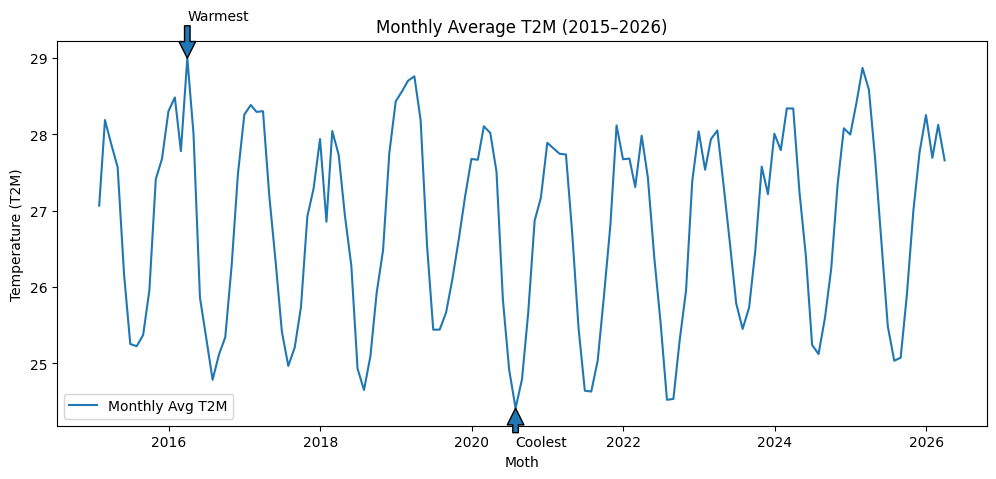

In [169]:



# Find warmest and coolest months
warmest_date = monthly_t2m.idxmax()
coolest_date = monthly_t2m.idxmin()

warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_t2m, label="Monthly Avg T2M")

# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_date, warmest_value),
             xytext=(warmest_date, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_date, coolest_value),
             xytext=(coolest_date, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Moth")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()


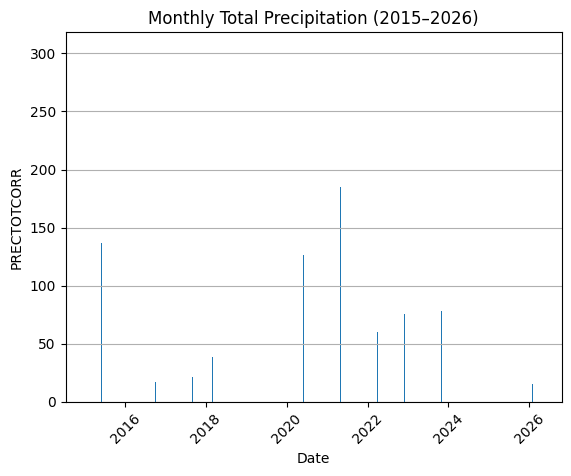

In [170]:
# Monthly average T2M
monthly_precip = df_clean["PRECTOTCORR"].resample("ME").sum()
plt.bar(monthly_precip.index, monthly_precip.values)
plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("PRECTOTCORR")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

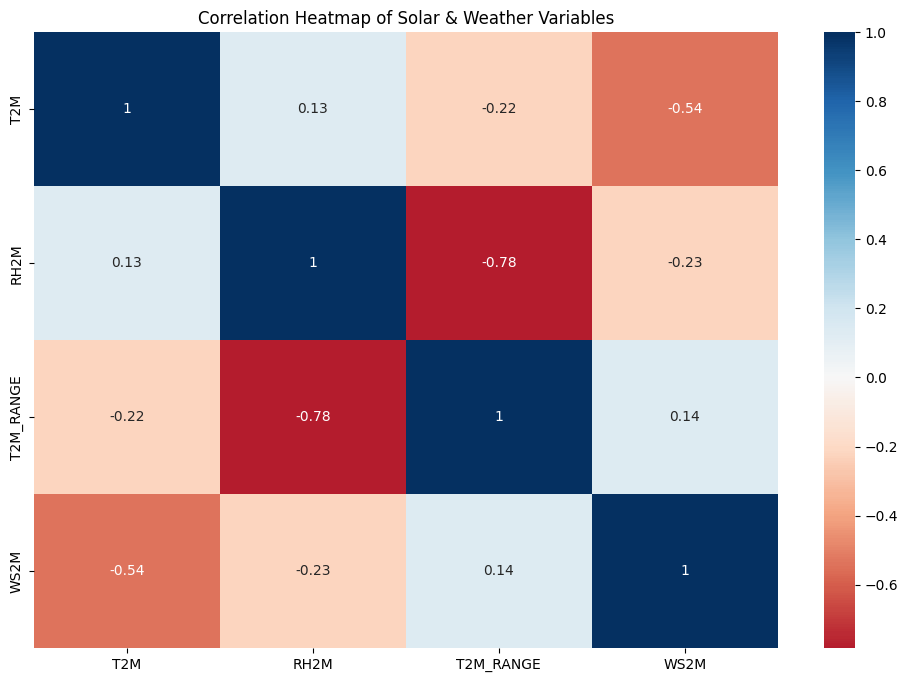

In [171]:

#selecting main columns for correlation
corr_cols = ['T2M', 'RH2M', 'T2M_RANGE', 'WS2M']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()

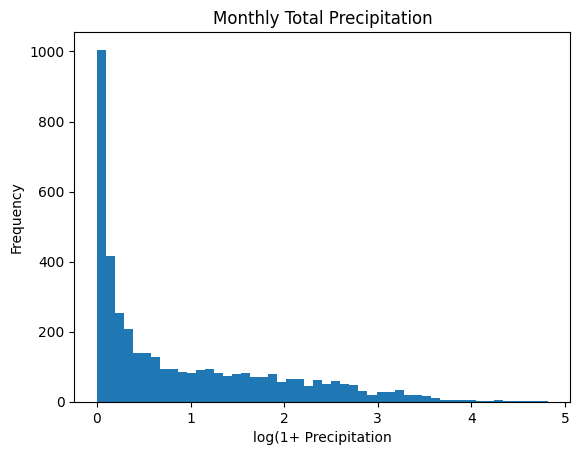

In [172]:


plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=50)
plt.title("Monthly Total Precipitation")
plt.xlabel("log(1+ Precipitation")
plt.ylabel("Frequency")
plt.show()

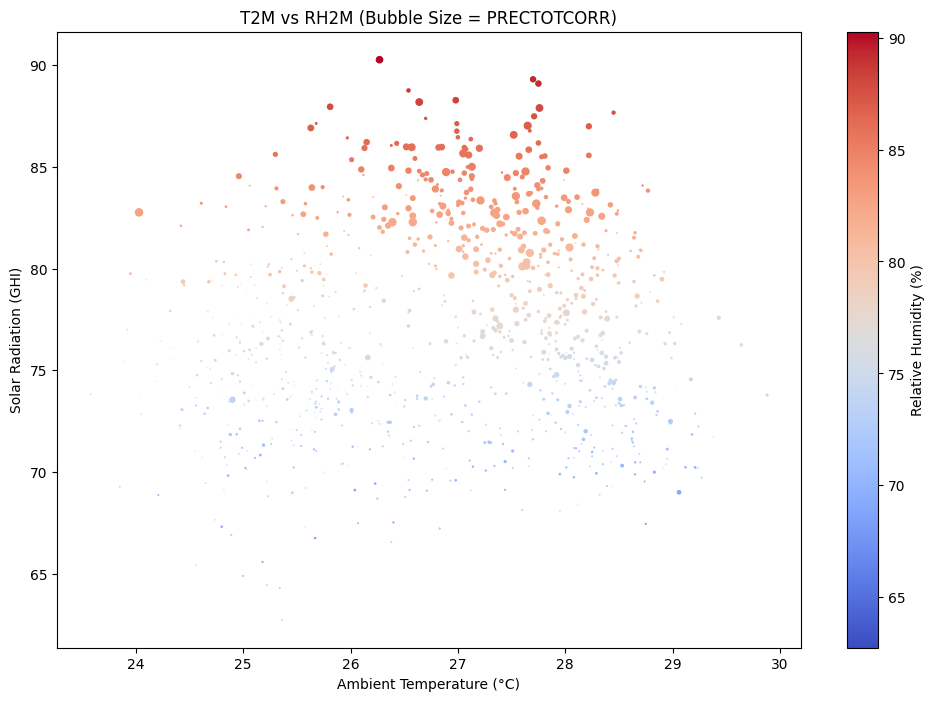

In [173]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['T2M'], sample_bubble['RH2M'], 
            s=sample_bubble['PRECTOTCORR'], # Size of bubble = Humidity 
            c=sample_bubble['RH2M'], # Color can also = Humidity
            cmap='coolwarm')

plt.title('T2M vs RH2M (Bubble Size = PRECTOTCORR)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Solar Radiation (GHI)')
plt.colorbar(label='Relative Humidity (%)')
plt.show()
